# Sklearn 文本表示与图像基础
## TF-IDF 二维可视化 + RGB/BGR、灰度化与边缘检测

**适合人群**：掌握基本 Python、NumPy 和 Matplotlib，但尚未系统学习文本特征与图像处理的新手。  
**运行方式**：从上到下逐个运行 Cell，并在每个练习处修改代码、记录现象。  
**数据依赖**：全部示例离线生成，不需要下载语料或图片。

---

## 核心学习目标

完成本 Notebook 后，应能：

1. 解释“文本为什么必须先转换成数值特征”。
2. 使用 `TfidfVectorizer` 将多篇文本转换成 TF-IDF 稀疏矩阵。
3. 查看词表、矩阵形状和每篇文档的重要词。
4. 使用 `TruncatedSVD` 将高维 TF-IDF 特征降到二维并绘制散点图。
5. 了解 t-SNE 的用途，并完成一个小规模二维可视化对比。
6. 理解 RGB 与 BGR 的通道顺序差异。
7. 使用 OpenCV 完成 RGB/BGR 转换、灰度化和高斯模糊。
8. 使用 Canny 完成边缘检测，并观察阈值变化的影响。
9. 使用 Sobel 梯度辅助理解“边缘是像素变化较大的位置”。
10. 独立完成一个文本小实验和一个图像小实验。

> 本实训强调“先跑通完整流程，再理解每个参数”。不要求第一次学习就记住全部数学细节。

### 文本主线

原始文本  
→ 简单清洗  
→ `TfidfVectorizer`  
→ 高维稀疏矩阵  
→ `TruncatedSVD` / t-SNE  
→ 二维散点图

### 图像主线

RGB 图像  
→ 转换为 OpenCV 的 BGR  
→ 灰度化  
→ 高斯模糊  
→ Canny / Sobel  
→ 边缘图

In [1]:
import sys
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

try:
    import cv2
except ImportError:
    cv2 = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Python:", sys.version.split()[0])
print("scikit-learn:", sklearn.__version__)
print("OpenCV:", cv2.__version__ if cv2 is not None else "未安装")

Python: 3.12.4
scikit-learn: 1.9.0
OpenCV: 5.0.0


# 第一部分：文本转换为 TF-IDF 特征
## 1. 为什么文本不能直接交给模型

机器学习模型通常接收数值矩阵，而不是自然语言句子。

假设有三篇文档：

- 文档 1：`machine learning classifies text`
- 文档 2：`computer vision classifies images`
- 文档 3：`security models detect harmful content`

TF-IDF 会把每篇文档转换成一个向量。向量的每一列对应一个词或词组，每个数值表示该词对当前文档的重要程度。

## 2. TF-IDF 的直观含义

TF-IDF 由两部分组成：

\[
\text{TF-IDF}(t,d)=\text{TF}(t,d)\times \text{IDF}(t)
\]

- **TF**：词 \(t\) 在文档 \(d\) 中出现得多不多。
- **IDF**：词 \(t\) 在全部文档中是否少见。
- 一个词在当前文档中频繁出现，但在其他文档中较少出现时，TF-IDF 通常较高。

例如：

- `the` 在很多英文文档中都出现，区分能力弱。
- `canny` 只在边缘检测文档中出现，区分能力较强。
## 3. 准备一个离线小语料

In [3]:
documents = [
    # NLP
    "text classification uses tf idf features",
    "language models learn representations from text",
    "word frequency helps represent documents",
    "sentiment analysis predicts positive or negative text",
    "tokenization splits a sentence into words",
    "document vectors support text retrieval",
    "natural language processing studies human language",
    "sparse features are common in text classification",

    # Computer Vision
    "image classification uses visual features",
    "computer vision detects objects in images",
    "rgb images contain red green and blue channels",
    "grayscale images contain one intensity channel",
    "canny detects edges in an image",
    "convolutional networks learn image patterns",
    "opencv reads color images in bgr order",
    "sobel filters estimate image gradients",

    # Security
    "security systems detect harmful online content",
    "malware detection classifies suspicious programs",
    "content moderation identifies unsafe messages",
    "anomaly detection finds unusual behavior",
    "phishing detection analyzes malicious messages",
    "network security monitors abnormal traffic",
    "robust models resist adversarial examples",
    "safe artificial intelligence reduces harmful outputs",
]

labels = (
    ["NLP"] * 8
    + ["Vision"] * 8
    + ["Security"] * 8
)

text_df = pd.DataFrame({
    "text": documents,
    "label": labels,
})

display(text_df.head(10))
print("文档数量：", len(text_df))
print("类别分布：")
display(text_df["label"].value_counts())

,text,label
0,text classification uses tf idf features,NLP
1,language models learn representations from text,NLP
2,word frequency helps represent documents,NLP
3,sentiment analysis predicts positive or negati...,NLP
4,tokenization splits a sentence into words,NLP
5,document vectors support text retrieval,NLP
6,natural language processing studies human lang...,NLP
7,sparse features are common in text classification,NLP
8,image classification uses visual features,Vision
9,computer vision detects objects in images,Vision


文档数量： 24
类别分布：


label
NLP         8
Vision      8
Security    8
Name: count, dtype: int64

## 4. 最小文本清洗

新手阶段先完成三个操作：

1. 转成小写；
2. 删除数字和特殊符号；
3. 合并多余空格。

实际项目还可能包含分词、词形还原、停用词表和领域词典。

In [4]:
def preprocess_en(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

text_df["clean_text"] = text_df["text"].apply(preprocess_en)

display(text_df[["text", "clean_text"]].head())

,text,clean_text
0,text classification uses tf idf features,text classification uses tf idf features
1,language models learn representations from text,language models learn representations from text
2,word frequency helps represent documents,word frequency helps represent documents
3,sentiment analysis predicts positive or negati...,sentiment analysis predicts positive or negati...
4,tokenization splits a sentence into words,tokenization splits a sentence into words


# 5. 使用 TfidfVectorizer

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=1,
    max_features=120,
    sublinear_tf=True,
)

X_tfidf = vectorizer.fit_transform(text_df["clean_text"])

print("TF-IDF 类型：", type(X_tfidf))
print("TF-IDF 形状：", X_tfidf.shape)
print("非零元素数量：", X_tfidf.nnz)
print("矩阵稀疏率：", round(1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]), 4))

TF-IDF 类型： <class 'scipy.sparse._csr.csr_matrix'>
TF-IDF 形状： (24, 120)
非零元素数量： 149
矩阵稀疏率： 0.9483


### 形状怎么理解

若输出为：

```text
(24, 120)
```

表示：

- 24 行：24 篇文档；
- 120 列：最多 120 个词或词组特征。

TF-IDF 通常是**稀疏矩阵**，因为一篇短文只会使用词表中的少量词。
## 5.1 查看词表

In [6]:
feature_names = vectorizer.get_feature_names_out()

print("词表大小：", len(feature_names))
print("前 40 个词或词组：")
print(feature_names[:40])

词表大小： 120
前 40 个词或词组：
['abnormal' 'abnormal traffic' 'adversarial' 'adversarial examples'
 'analysis' 'anomaly' 'anomaly detection' 'artificial'
 'artificial intelligence' 'bgr' 'bgr order' 'blue' 'blue channels'
 'canny' 'canny detects' 'channel' 'channels' 'classification'
 'classification uses' 'classifies' 'classifies suspicious' 'color'
 'color images' 'common' 'common text' 'computer' 'computer vision'
 'contain' 'contain intensity' 'contain red' 'content'
 'content moderation' 'convolutional' 'convolutional networks' 'detect'
 'detect harmful' 'detection' 'detection analyzes' 'detection classifies'
 'detection finds']


## 5.2 把前几篇文档的 TF-IDF 转成表格

In [7]:
tfidf_preview = pd.DataFrame(
    X_tfidf[:5].toarray(),
    columns=feature_names,
)

# 只显示至少在前 5 篇中出现一次的列
used_columns = tfidf_preview.columns[(tfidf_preview > 0).any(axis=0)]

display(tfidf_preview[used_columns].round(3))

,analysis,classification,classification uses,documents,features,frequency,frequency helps,helps,helps represent,idf,...,language models,learn,learn representations,models,models learn,negative,negative text,text,text classification,uses
0,0.000,0.325,0.358,0.000,0.325,0.000,0.000,0.000,0.000,0.404,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.278,0.358,0.358
1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.414,0.367,0.414,0.367,0.414,0.000,0.000,0.285,0.000,0.000
2,0.000,0.000,0.000,0.447,0.000,0.447,0.447,0.447,0.447,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.537,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.537,0.537,0.369,0.000,0.000
4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


## 5.3 查看每篇文档权重最高的词

In [8]:
def top_tfidf_terms(row_index, matrix, names, top_n=5):
    row = matrix[row_index].toarray().ravel()
    top_indices = row.argsort()[::-1][:top_n]

    return [
        (names[index], float(row[index]))
        for index in top_indices
        if row[index] > 0
    ]

for index in [0, 8, 16]:
    print(f"\n文档 {index} | 类别={text_df.loc[index, 'label']}")
    print(text_df.loc[index, "text"])
    print(top_tfidf_terms(index, X_tfidf, feature_names, top_n=6))


文档 0 | 类别=NLP
text classification uses tf idf features
[('idf', 0.40440862456938903), ('idf features', 0.40440862456938903), ('uses', 0.35790090851313167), ('text classification', 0.35790090851313167), ('classification uses', 0.35790090851313167), ('features', 0.32490315883624976)]

文档 8 | 类别=Vision
image classification uses visual features
[('image classification', 0.47645393549613624), ('uses', 0.42166087966174315), ('classification uses', 0.42166087966174315), ('features', 0.3827845878595906), ('classification', 0.3827845878595906), ('image', 0.3526297932256154)]

文档 16 | 类别=Security
security systems detect harmful online content
[('online', 0.3688639506485176), ('online content', 0.3688639506485176), ('harmful online', 0.3688639506485176), ('detect', 0.3688639506485176), ('detect harmful', 0.3688639506485176), ('content', 0.3264439357479524)]


### 观察问题

1. NLP 文档的重要词是否包含 `text`、`language`、`document`？
2. Vision 文档的重要词是否包含 `image`、`rgb`、`canny`？
3. Security 文档的重要词是否包含 `security`、`detection`、`harmful`？
4. 某些 bigram（两个连续词）是否比单个词更具体？
# 第二部分：将 TF-IDF 特征降到二维
TF-IDF 可能有几十、几百甚至几十万维，不能直接画在二维平面中。

降维的目标是：

\[
\text{高维文档向量} \rightarrow (x,y)
\]

每个二维点代表一篇文档。彼此较近的点通常表示特征更相似。

本 Notebook 使用：

- **TruncatedSVD**：适合稀疏矩阵、速度快、结果较稳定，作为主方法。
- **t-SNE**：擅长观察局部聚类，但对参数和随机种子敏感，作为选学对比。

## 6. 使用 TruncatedSVD 降到二维

In [9]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(
    n_components=2,
    random_state=RANDOM_STATE,
)

X_2d_svd = svd.fit_transform(X_tfidf)

print("二维结果形状：", X_2d_svd.shape)
print("两个维度解释的方差比例：", svd.explained_variance_ratio_.round(4))
print("累计解释比例：", round(svd.explained_variance_ratio_.sum(), 4))

二维结果形状： (24, 2)
两个维度解释的方差比例： [0.0664 0.0487]
累计解释比例： 0.1151


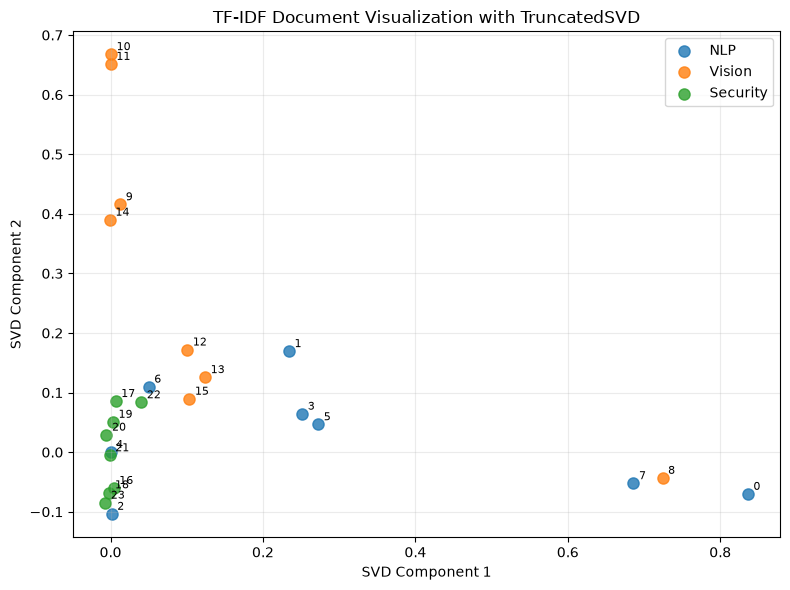

In [10]:
label_order = ["NLP", "Vision", "Security"]

plt.figure(figsize=(8, 6))

for label in label_order:
    mask = text_df["label"].to_numpy() == label
    plt.scatter(
        X_2d_svd[mask, 0],
        X_2d_svd[mask, 1],
        label=label,
        s=65,
        alpha=0.8,
    )

for index, (x_value, y_value) in enumerate(X_2d_svd):
    plt.annotate(
        str(index),
        (x_value, y_value),
        xytext=(4, 3),
        textcoords="offset points",
        fontsize=8,
    )

plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.title("TF-IDF Document Visualization with TruncatedSVD")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### 如何阅读散点图

- 每个点是一篇文档。
- 点旁的数字是文档编号。
- 相同类别是否大致靠近？
- 不同类别是否完全分开？若没有，说明某些文档共享了相似词汇。
- 二维图只是高维特征的压缩表示，不能完整保留所有信息。

## 6.1 查看二维坐标与原文

In [11]:
svd_result_df = text_df[["label", "text"]].copy()
svd_result_df["svd_x"] = X_2d_svd[:, 0]
svd_result_df["svd_y"] = X_2d_svd[:, 1]

display(svd_result_df.round({"svd_x": 3, "svd_y": 3}))

,label,text,svd_x,svd_y
0,NLP,text classification uses tf idf features,0.836,-0.070
1,NLP,language models learn representations from text,0.234,0.169
2,NLP,word frequency helps represent documents,0.002,-0.104
3,NLP,sentiment analysis predicts positive or negati...,0.252,0.064
4,NLP,tokenization splits a sentence into words,0.000,0.000
5,NLP,document vectors support text retrieval,0.273,0.047
6,NLP,natural language processing studies human lang...,0.050,0.110
7,NLP,sparse features are common in text classification,0.686,-0.052
8,Vision,image classification uses visual features,0.724,-0.043
9,Vision,computer vision detects objects in images,0.013,0.416


## 7. 选学：使用 t-SNE 做二维可视化
t-SNE 更关注“邻近样本是否保持邻近”，但要注意：

- 不同运行结果可能变化；
- 点之间的全局距离不宜过度解释；
- `perplexity` 必须小于样本数量；
- 对大数据计算较慢。

这里先用 SVD 压到较低维，再使用 t-SNE。

In [12]:
from sklearn.manifold import TSNE

svd_for_tsne = TruncatedSVD(
    n_components=min(10, X_tfidf.shape[1] - 1),
    random_state=RANDOM_STATE,
)

X_small = svd_for_tsne.fit_transform(X_tfidf)

tsne = TSNE(
    n_components=2,
    perplexity=5,
    init="pca",
    learning_rate="auto",
    random_state=RANDOM_STATE,
)

X_2d_tsne = tsne.fit_transform(X_small)

print("t-SNE 结果形状：", X_2d_tsne.shape)

t-SNE 结果形状： (24, 2)


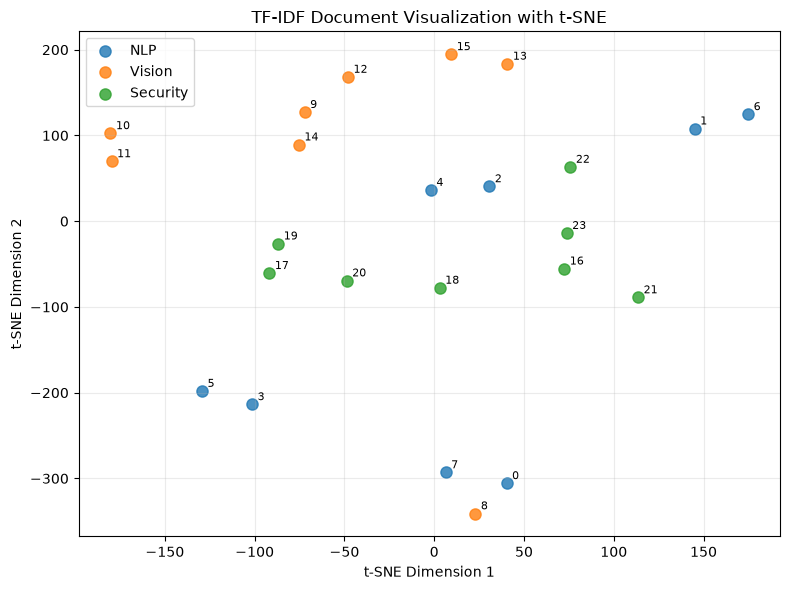

In [13]:
plt.figure(figsize=(8, 6))

for label in label_order:
    mask = text_df["label"].to_numpy() == label
    plt.scatter(
        X_2d_tsne[mask, 0],
        X_2d_tsne[mask, 1],
        label=label,
        s=65,
        alpha=0.8,
    )

for index, (x_value, y_value) in enumerate(X_2d_tsne):
    plt.annotate(
        str(index),
        (x_value, y_value),
        xytext=(4, 3),
        textcoords="offset points",
        fontsize=8,
    )

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("TF-IDF Document Visualization with t-SNE")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### SVD 与 t-SNE 的新手对比

| 方法 | 优点 | 注意点 |
|---|---|---|
| TruncatedSVD | 快、稳定、适合稀疏矩阵 | 二维可能不能明显分开类别 |
| t-SNE | 聚类结构常更直观 | 对参数敏感，不适合解释全局距离 |

本实训中应先掌握 SVD，再把 t-SNE 当作补充工具。

# 8. 可选扩展：TF-IDF + 逻辑回归最小分类
二维可视化用于观察数据结构；真正分类时，应使用原始高维 TF-IDF 特征，而不是只使用二维坐标。

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

text_classifier = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            stop_words="english",
            ngram_range=(1, 2),
            sublinear_tf=True,
        ),
    ),
    (
        "clf",
        LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE,
        ),
    ),
])

cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scores = cross_val_score(
    text_classifier,
    text_df["clean_text"],
    text_df["label"],
    cv=cv,
    scoring="accuracy",
)

print("每折 Accuracy：", scores.round(3))
print("平均 Accuracy：", round(scores.mean(), 3))

每折 Accuracy： [0.833 0.5   1.    1.   ]
平均 Accuracy： 0.833


这个结果只能用于练习流程：

- 数据非常少；
- 文档是人工构造的；
- 不能把该分数当作真实模型性能。

重点是理解 `Pipeline` 可以把 TF-IDF 和分类器连接成一个完整流程。

# 第三部分：理解 RGB 与 BGR
## 9. RGB 与 BGR 的区别

一张彩色图通常有三个通道：

- R：Red
- G：Green
- B：Blue

Matplotlib 默认按 **RGB** 显示图像。

OpenCV 的 `cv2.imread()` 默认读取为 **BGR**：

- 第 0 通道：Blue
- 第 1 通道：Green
- 第 2 通道：Red

若把 BGR 图像直接交给 Matplotlib，红色和蓝色通常会交换。

## 9.1 生成一张离线测试图

In [16]:
if cv2 is None:
    raise ImportError("未安装 opencv-python，请先执行：pip install opencv-python")

height, width = 240, 320

img_rgb = np.full(
    (height, width, 3),
    fill_value=245,
    dtype=np.uint8,
)

# RGB 图像中绘制三个颜色区域
img_rgb[25:105, 25:115] = [230, 60, 60]      # 红色矩形
img_rgb[40:145, 130:220] = [60, 190, 80]     # 绿色矩形
img_rgb[80:190, 235:305] = [60, 100, 230]    # 蓝色矩形

# 增加黑色斜线和白色圆形，制造明显边缘
cv2.line(img_rgb, (20, 210), (300, 25), (20, 20, 20), thickness=5)
cv2.circle(img_rgb, (165, 180), 28, (255, 255, 255), thickness=-1)
cv2.circle(img_rgb, (165, 180), 28, (30, 30, 30), thickness=3)

print("图像形状：", img_rgb.shape)
print("数据类型：", img_rgb.dtype)
print("像素范围：", img_rgb.min(), "到", img_rgb.max())

图像形状： (240, 320, 3)
数据类型： uint8
像素范围： 20 到 255


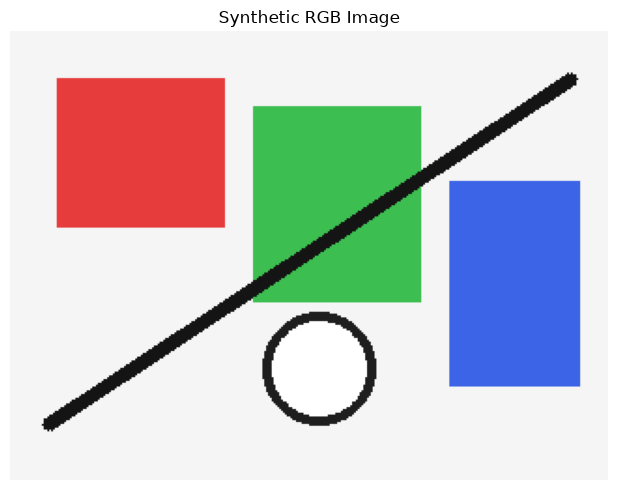

In [17]:
plt.figure(figsize=(7, 5))
plt.imshow(img_rgb)
plt.title("Synthetic RGB Image")
plt.axis("off")
plt.tight_layout()
plt.show()

## 9.2 RGB 转 BGR

In [18]:
img_bgr = cv2.cvtColor(
    img_rgb,
    cv2.COLOR_RGB2BGR,
)

print("RGB 左上红色区域像素：", img_rgb[50, 50])
print("BGR 同一位置像素：", img_bgr[50, 50])

RGB 左上红色区域像素： [230  60  60]
BGR 同一位置像素： [ 60  60 230]


对于红色像素：

- RGB：`[230, 60, 60]`
- BGR：`[60, 60, 230]`

颜色没有改变，只是通道顺序改变。

## 9.3 演示错误显示与正确显示

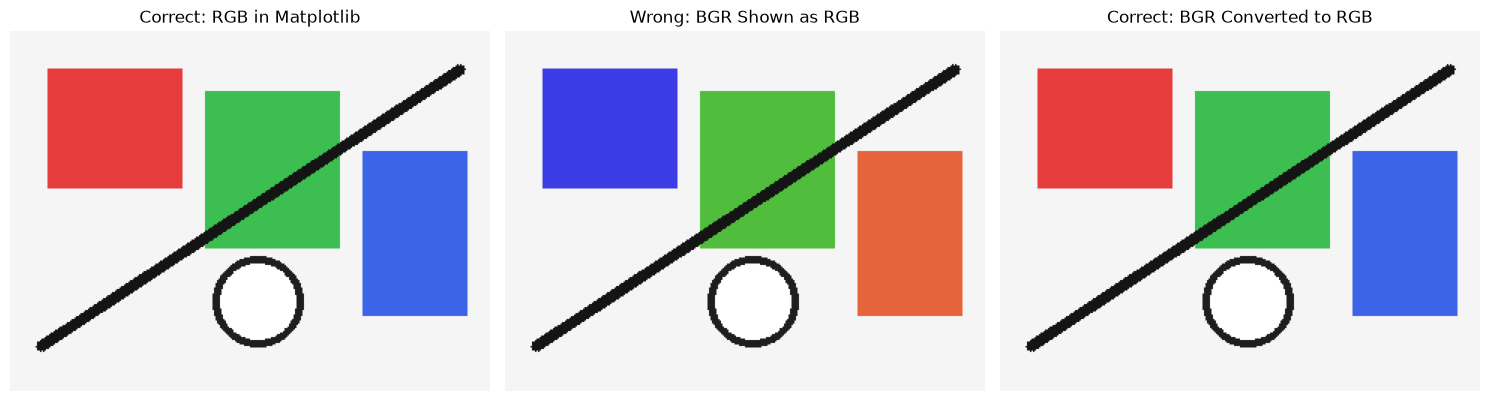

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(img_rgb)
axes[0].set_title("Correct: RGB in Matplotlib")

axes[1].imshow(img_bgr)
axes[1].set_title("Wrong: BGR Shown as RGB")

img_rgb_recovered = cv2.cvtColor(
    img_bgr,
    cv2.COLOR_BGR2RGB,
)

axes[2].imshow(img_rgb_recovered)
axes[2].set_title("Correct: BGR Converted to RGB")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()

### 必须记住

```python
img_bgr = cv2.imread("sample.jpg")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
```

OpenCV 处理时可以继续使用 BGR；交给 Matplotlib 显示前通常转换为 RGB。

# 10. 灰度化

灰度图只有一个强度通道。每个像素表示亮度，不再分别保存红、绿、蓝。

灰度化常用于：

- 边缘检测；
- 形状分析；
- 降低计算量；
- 不需要颜色信息的传统视觉算法。

In [20]:
gray = cv2.cvtColor(
    img_bgr,
    cv2.COLOR_BGR2GRAY,
)

print("彩色图 shape：", img_bgr.shape)
print("灰度图 shape：", gray.shape)
print("灰度像素范围：", gray.min(), "到", gray.max())

彩色图 shape： (240, 320, 3)
灰度图 shape： (240, 320)
灰度像素范围： 20 到 255


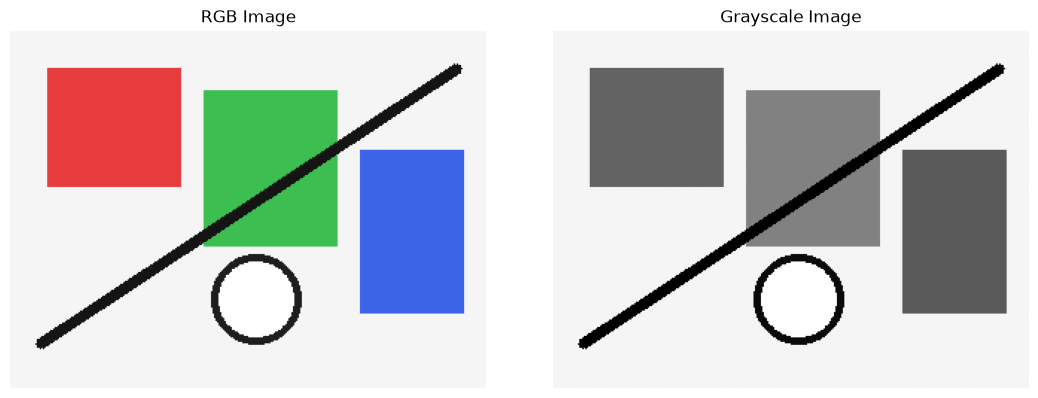

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].imshow(img_rgb)
axes[0].set_title("RGB Image")
axes[0].axis("off")

axes[1].imshow(gray, cmap="gray")
axes[1].set_title("Grayscale Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 新手观察

- 彩色图 shape 为 `(H, W, 3)`。
- 灰度图 shape 为 `(H, W)`。
- 灰度图不是“简单取某一个颜色通道”，而是根据颜色亮度组合得到。

# 11. 边缘检测前为什么要模糊
边缘检测会寻找像素值变化明显的位置。

噪声也会造成像素突变，因此通常先使用高斯模糊：

```text
灰度图 → 高斯模糊 → Canny
```

模糊过弱可能保留太多噪声；模糊过强可能抹掉细小边缘。

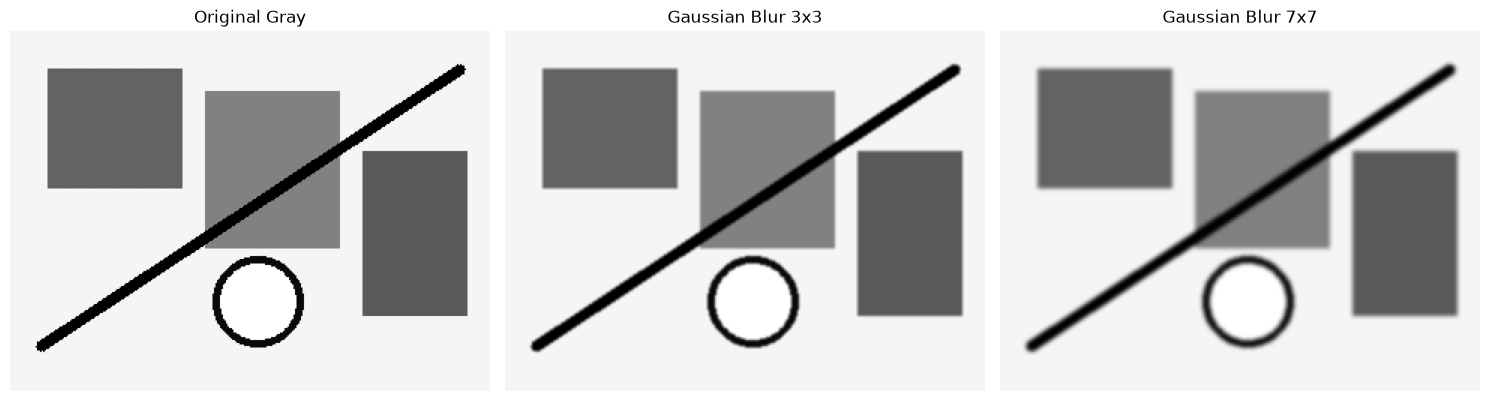

In [23]:
blurred_3 = cv2.GaussianBlur(gray, (3, 3), 0)
blurred_7 = cv2.GaussianBlur(gray, (7, 7), 0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original Gray")

axes[1].imshow(blurred_3, cmap="gray")
axes[1].set_title("Gaussian Blur 3x3")

axes[2].imshow(blurred_7, cmap="gray")
axes[2].set_title("Gaussian Blur 7x7")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()

# 12. 使用 Canny 进行边缘检测
Canny 最常用的两个参数：

```python
cv2.Canny(image, threshold1, threshold2)
```

- `threshold1`：低阈值；
- `threshold2`：高阈值。

直观规律：

- 阈值较低：检测到更多边缘，也可能包含更多噪声。
- 阈值较高：只保留更明显的边缘，也可能漏掉细节。

In [24]:
edges_low = cv2.Canny(
    blurred_3,
    threshold1=20,
    threshold2=70,
)

edges_medium = cv2.Canny(
    blurred_3,
    threshold1=50,
    threshold2=150,
)

edges_high = cv2.Canny(
    blurred_3,
    threshold1=100,
    threshold2=220,
)

edge_counts = pd.Series({
    "Low thresholds": int((edges_low > 0).sum()),
    "Medium thresholds": int((edges_medium > 0).sum()),
    "High thresholds": int((edges_high > 0).sum()),
})

display(edge_counts.rename("边缘像素数"))

Low thresholds       2200
Medium thresholds    2200
High thresholds      2200
Name: 边缘像素数, dtype: int64

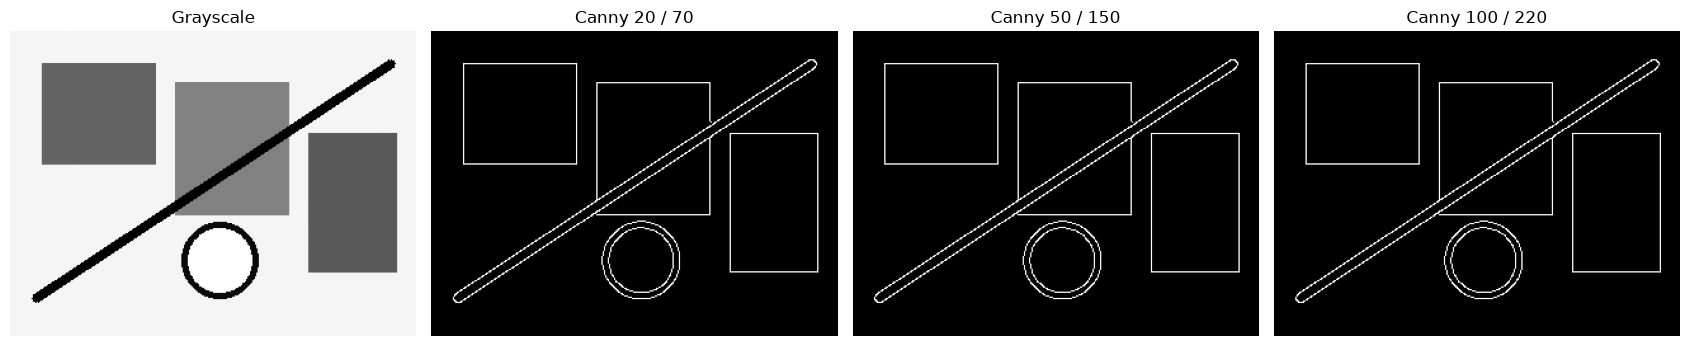

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Grayscale")

axes[1].imshow(edges_low, cmap="gray")
axes[1].set_title("Canny 20 / 70")

axes[2].imshow(edges_medium, cmap="gray")
axes[2].set_title("Canny 50 / 150")

axes[3].imshow(edges_high, cmap="gray")
axes[3].set_title("Canny 100 / 220")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()

### 观察任务

1. 哪组阈值检测到的边缘最多？
2. 哪组阈值丢失了较弱的边缘？
3. 白色区域表示什么？
4. Canny 的输出为什么只有 0 和 255？
# 13. 使用 Sobel 理解梯度
Sobel 分别估计水平方向和垂直方向的亮度变化：

- `sobel_x`：对水平方向坐标变化敏感；
- `sobel_y`：对垂直方向坐标变化敏感；
- 梯度幅值较大的位置通常是边缘。

In [27]:
sobel_x = cv2.Sobel(
    gray,
    cv2.CV_64F,
    dx=1,
    dy=0,
    ksize=3,
)

sobel_y = cv2.Sobel(
    gray,
    cv2.CV_64F,
    dx=0,
    dy=1,
    ksize=3,
)

gradient_magnitude = np.sqrt(
    sobel_x**2 + sobel_y**2
)

gradient_magnitude_normalized = cv2.normalize(
    gradient_magnitude,
    None,
    0,
    255,
    cv2.NORM_MINMAX,
).astype(np.uint8)

print("Sobel X 范围：", sobel_x.min(), "到", sobel_x.max())
print("梯度幅值范围：", gradient_magnitude.min(), "到", gradient_magnitude.max())

Sobel X 范围： -900.0 到 900.0
梯度幅值范围： 0.0 到 1006.2305898749054


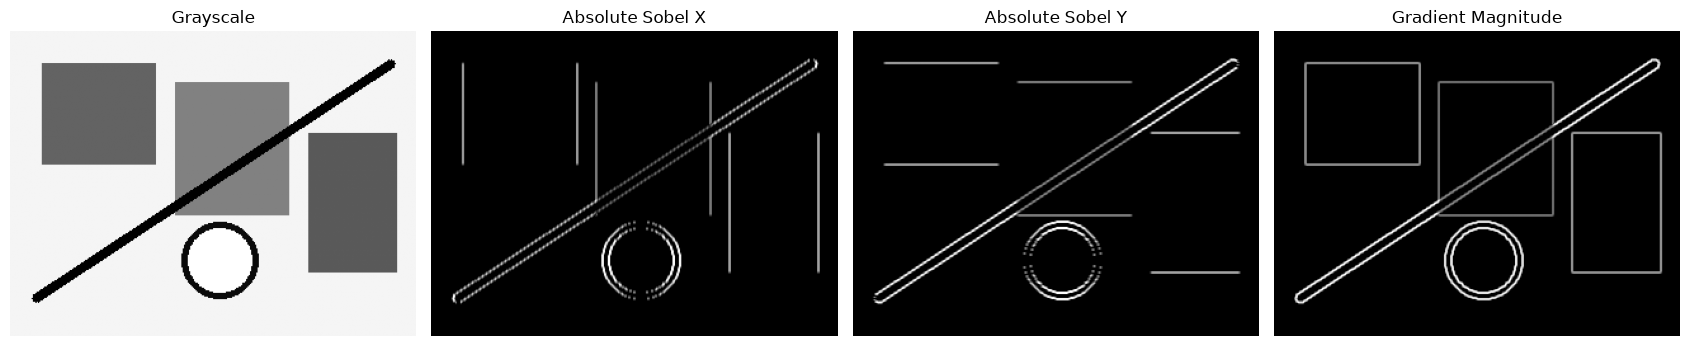

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Grayscale")

axes[1].imshow(np.abs(sobel_x), cmap="gray")
axes[1].set_title("Absolute Sobel X")

axes[2].imshow(np.abs(sobel_y), cmap="gray")
axes[2].set_title("Absolute Sobel Y")

axes[3].imshow(gradient_magnitude_normalized, cmap="gray")
axes[3].set_title("Gradient Magnitude")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()

### Canny 与 Sobel 的区别

| 方法 | 输出特点 | 适合用途 |
|---|---|---|
| Sobel | 连续梯度强度，可观察方向 | 理解亮度变化、构造传统特征 |
| Canny | 较细的二值边缘 | 提取清晰轮廓、后续形状分析 |

新手阶段先理解流程，不必手工实现 Canny 的全部内部步骤。`

# 14. 可选扩展：颜色通道与直方图

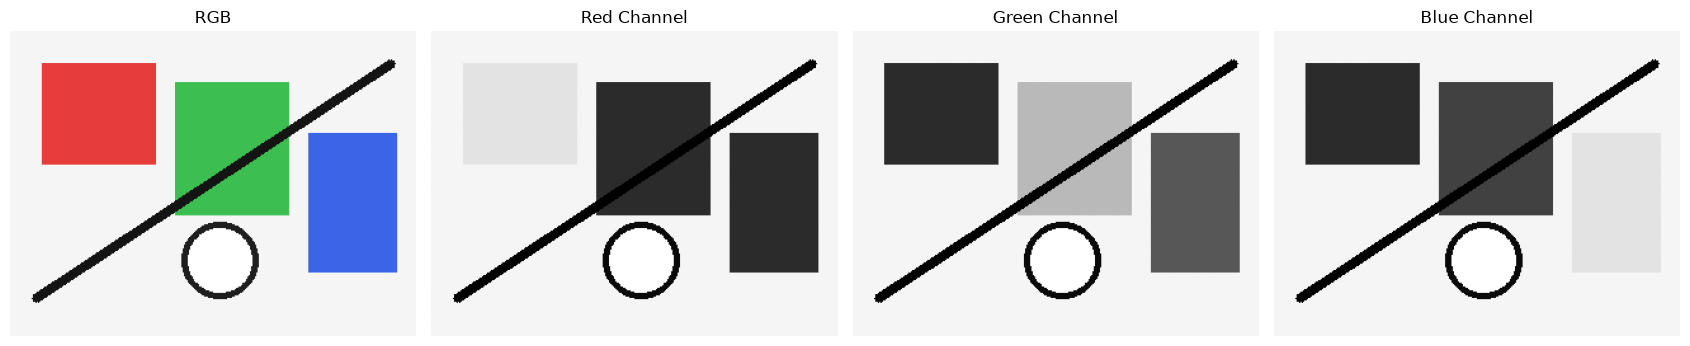

In [29]:
red_channel = img_rgb[:, :, 0]
green_channel = img_rgb[:, :, 1]
blue_channel = img_rgb[:, :, 2]

fig, axes = plt.subplots(1, 4, figsize=(17, 4))

axes[0].imshow(img_rgb)
axes[0].set_title("RGB")

axes[1].imshow(red_channel, cmap="gray")
axes[1].set_title("Red Channel")

axes[2].imshow(green_channel, cmap="gray")
axes[2].set_title("Green Channel")

axes[3].imshow(blue_channel, cmap="gray")
axes[3].set_title("Blue Channel")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()

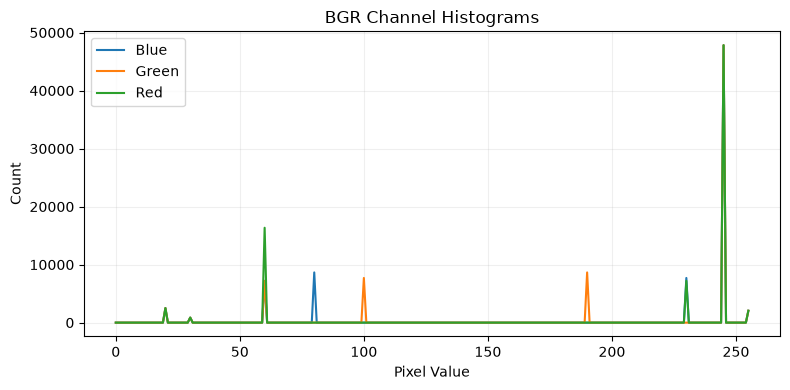

In [30]:
plt.figure(figsize=(8, 4))

for channel_index, channel_name in enumerate(["Blue", "Green", "Red"]):
    histogram = cv2.calcHist(
        [img_bgr],
        [channel_index],
        None,
        [256],
        [0, 256],
    )
    plt.plot(histogram, label=channel_name)

plt.xlabel("Pixel Value")
plt.ylabel("Count")
plt.title("BGR Channel Histograms")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 15. 独立练习
## 练习 1：修改文本语料

向 `documents` 中分别增加：

- 2 篇 NLP 文档；
- 2 篇 Vision 文档；
- 2 篇 Security 文档。

重新运行：

1. TF-IDF；
2. TruncatedSVD；
3. 二维散点图。

记录新增文档是否靠近预期类别。
## 练习 2：修改 TF-IDF 参数

依次比较：

```python
ngram_range=(1, 1)
ngram_range=(1, 2)
```

回答：

1. 词表大小如何变化？
2. bigram 是否让某些主题词更具体？
3. 稀疏率如何变化？
## 练习 3：比较降维方法

比较 SVD 和 t-SNE 的二维图：

- 哪个结果更稳定？
- 哪个图中的类别聚集更明显？
- 为什么不能只根据二维图判断分类模型一定很好？
## 练习 4：修改 Canny 阈值

至少测试三组参数，例如：

```python
(10, 40)
(50, 150)
(150, 250)
```

记录每组参数的：

- 边缘像素数量；
- 细节保留情况；
- 是否出现明显漏检。
## 练习 5：处理自己的图片

将下面的路径改为自己的图片：

```python
image_path = "sample.jpg"
```

建议流程：

```python
real_bgr = cv2.imread(image_path)

if real_bgr is None:
    raise FileNotFoundError("图像路径错误或文件无法读取")

real_rgb = cv2.cvtColor(real_bgr, cv2.COLOR_BGR2RGB)
real_gray = cv2.cvtColor(real_bgr, cv2.COLOR_BGR2GRAY)
real_blurred = cv2.GaussianBlur(real_gray, (5, 5), 0)
real_edges = cv2.Canny(real_blurred, 50, 150)
```

比较程序生成图和真实照片的边缘检测效果。
# 练习 5 模板：填写路径后再运行

In [31]:
from pathlib import Path

image_path = Path("sample.jpg")

if image_path.exists():
    real_bgr = cv2.imread(str(image_path))

    if real_bgr is None:
        raise ValueError("文件存在，但 OpenCV 无法读取该图像")

    real_rgb = cv2.cvtColor(real_bgr, cv2.COLOR_BGR2RGB)
    real_gray = cv2.cvtColor(real_bgr, cv2.COLOR_BGR2GRAY)
    real_blurred = cv2.GaussianBlur(real_gray, (5, 5), 0)
    real_edges = cv2.Canny(real_blurred, 50, 150)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].imshow(real_rgb)
    axes[0].set_title("Real RGB")

    axes[1].imshow(real_gray, cmap="gray")
    axes[1].set_title("Real Grayscale")

    axes[2].imshow(real_edges, cmap="gray")
    axes[2].set_title("Real Canny Edges")

    for axis in axes:
        axis.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("未找到 sample.jpg。请放入自己的图片后重新运行本 Cell。")

未找到 sample.jpg。请放入自己的图片后重新运行本 Cell。
